# Classical-only validation — Xie et al. (2021) empírico vs. fórmula fechada

**Objetivo**: testar rapidamente (sem GPU, sem treino de rede, ~1-2 min) se a
correção do gerador de TAG (`K=70 > L=64`, burn-in adequado) resolveu a
divergência entre a curva empírica (limiar Gaussiano D3F sobre `tau_eq`) e a
curva teórica fechada (Xie et al. 2021, Eq. 40-41/43-44, Rayleigh-média).

Gera um dataset **pequeno, em memória**, usando exatamente as mesmas funções
já corrigidas do `nn01.ipynb` atual (copiadas verbatim abaixo) — não depende
do HDF5 de 300k amostras, que pode estar desatualizado (gerado antes da
correção de `K`).

**Diagnóstico prévio (fora deste notebook)**: rodando `generate_tag(K=70)`
isoladamente, `Σ(msg·tag_ref)` já bate com o esperado sob independência
(`mean≈1.0`, `std≈19.4`, previsto por CLT `≈18.5`) — ou seja, o gerador em
si já está corrigido. Se a divergência ainda aparecer neste notebook (que usa
dados 100% frescos), o problema está em outro lugar; se NÃO aparecer, confirma
que o `.h5` de 300k amostras carregado pelo NN_02c está desatualizado e
precisa ser regenerado (Seção 4+6 do NN_01).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm as scipy_norm

np.random.seed(42)
print("Imports OK.")

Imports OK.


## 1. Funções de geração (copiadas verbatim do NN_01 atual, já corrigidas: K=70)

In [2]:
def modulator_bpsk(L, seed=None):
    if seed is not None:
        np.random.seed(seed)
    bits = np.random.randint(0, 2, L)
    return 2 * bits - 1  # {+1, -1}

def _tent(x, beta=1e-6):
    """Tent map on [-1, 1]. Invariant measure: Uniform[-1,1] -> E[x]=0, E[x^2]=1/3."""
    if x < beta:
        return 2.0 / (beta + 1) * x + (1.0 - beta) / (beta + 1)
    return 2.0 / (beta - 1) * x - (beta + 1) / (beta - 1)

def generate_tag(msg, key, L, K=70):
    """Generate chaotic TAG. E[tag]=0, E[tag^2]~1/3.
    K deve ser MAIOR que L (garante burn-in>0 -- ver diagnostico anterior:
    K<L faz sigma=K-L<0, o slicing orb[sigma:] nao descarta nada, e a TAG
    fica correlacionada com a mensagem que gerou a semente.
    """
    msg_bits = ((msg + 1) // 2).astype(np.uint8)
    n        = min(K, len(msg_bits), len(key))
    m_pad    = np.resize(msg_bits[:n], K)
    k_pad    = np.resize(key[:n].astype(np.uint8), K)
    xor_seq  = np.bitwise_xor(m_pad, k_pad)

    packed   = np.packbits(xor_seq[:64])
    xor_int  = int.from_bytes(packed.tobytes(), 'big')
    xi       = (6 * xor_int**2 + xor_int + 1) % (2**64)
    x0       = (xi / (2**64 - 1)) * 2.0 - 1.0

    assert K > L, f"K deve ser MAIOR que L (K={K}, L={L})"
    warm_up = max(0, K - L)
    x = x0
    buf = np.empty(L, dtype=np.float64)
    k_out = 0
    for i in range(warm_up + L):
        x = _tent(x)
        if i >= warm_up:
            buf[k_out] = x
            k_out += 1

    std_buf = buf.std()
    if std_buf > 1e-10:
        buf = buf / (std_buf * np.sqrt(3))
    return buf

def rayleigh_channel(length, sigma_h=1/np.sqrt(2)):
    real_part = np.random.normal(0, sigma_h, length)
    imag_part = np.random.normal(0, sigma_h, length)
    return np.sqrt(real_part**2 + imag_part**2)

def awgn_channel(signal, snr_db, ref_signal=None):
    """Ruido calibrado por SNR NOMINAL (pre-fade), independente de h (AÇÃO 2 fix)."""
    ref = signal if ref_signal is None else ref_signal
    snr_linear   = 10**(snr_db / 10)
    signal_power = np.mean(np.abs(ref)**2)
    noise_power  = signal_power / snr_linear
    noise = np.random.normal(0, np.sqrt(noise_power), len(signal))
    return signal + noise

print("Funcoes de geracao definidas (K=70 fix aplicado).")

Funcoes de geracao definidas (K=70 fix aplicado).


## 2. Parametros alinhados com Xie et al. (2021)

In [3]:
L_FIXED = 64
K_KEY   = 70   # > L_FIXED (burn-in = 100)
RHO_S   = np.sqrt(0.9)
RHO_T   = np.sqrt(3 * (1 - RHO_S**2))   # = sqrt(0.3) ~ 0.5477  (rho_t^2*E[tag^2]=0.1, igual a Xie)
ALPHA_D3F = 0.01
Q_INV_D3F = scipy_norm.ppf(1 - ALPHA_D3F)
SNR_BINS = [0, 5, 10, 15, 20, 25, 30]

print(f"RHO_S={RHO_S:.6f} (rho_s^2={RHO_S**2:.4f})  RHO_T={RHO_T:.6f} (rho_t^2={RHO_T**2:.4f})")
print(f"Energia efetiva de tag: rho_t^2*E[tag^2] = {RHO_T**2/3:.4f}  (alvo Xie: 0.1000)")
print(f"alpha={ALPHA_D3F}  Q_inv={Q_INV_D3F:.4f}")

RHO_S=0.948683 (rho_s^2=0.9000)  RHO_T=0.547723 (rho_t^2=0.3000)
Energia efetiva de tag: rho_t^2*E[tag^2] = 0.1000  (alvo Xie: 0.1000)
alpha=0.01  Q_inv=2.3263


## 3. Diagnóstico live: correlação msg-tag (confirma se o fix de K está funcionando aqui e agora)

In [4]:
N_DIAG = 500
corrs = []
for _ in range(N_DIAG):
    msg = modulator_bpsk(L_FIXED)
    key = np.random.randint(0, 2, K_KEY)
    tag = generate_tag(msg, key, L_FIXED, K_KEY)
    corrs.append(np.dot(msg, tag))
corrs = np.array(corrs)

print(f"Sigma(msg*tag) -- media={corrs.mean():.3f}  std={corrs.std():.3f}")
print(f"  esperado sob independencia: media~0, std~sqrt(L*E[tag^2])={np.sqrt(L_FIXED/3):.2f}")
if abs(corrs.mean()) < 3 * corrs.std() / np.sqrt(N_DIAG):
    print("  -> OK: correlacao compativel com ZERO (dentro do erro padrao da media).")
else:
    print("  -> ATENCAO: correlacao residual detectada -- gerador ainda tem viés.")

Sigma(msg*tag) -- media=0.683  std=4.804
  esperado sob independencia: media~0, std~sqrt(L*E[tag^2])=4.62
  -> ATENCAO: correlacao residual detectada -- gerador ainda tem viés.


## 4. Geração de um dataset pequeno em memória (val + test), por bin de SNR

In [5]:
def generate_sample(snr_db, L, K, is_authentic):
    msg     = modulator_bpsk(L)
    key     = np.random.randint(0, 2, K)
    tag_ref = generate_tag(msg, key, L, K)

    h = rayleigh_channel(1)[0]
    h = max(h, 1e-6)

    if is_authentic:
        x = RHO_S * msg + RHO_T * tag_ref
    else:
        x = msg

    y = awgn_channel(h * x, snr_db, ref_signal=x)
    y_eq = y / h
    tau_eq = float(np.sum((y_eq - RHO_S * msg) * tag_ref) / RHO_T)
    return tau_eq, h, snr_db, int(is_authentic)


N_PER_HYP_VAL  = 3000   # amostras H0 por bin (para calibrar limiar) -- val
N_PER_HYP_TEST = 3000   # amostras H1 por bin (para medir PD) -- test

tau_val, snr_val, lbl_val   = [], [], []
tau_test, snr_test, lbl_test = [], [], []

for snr_center in SNR_BINS:
    # val: H0 apenas (para calibrar mu, sigma do limiar), janela +/-2.5dB igual ao NN_02c
    for _ in range(N_PER_HYP_VAL):
        snr_db = np.random.uniform(max(0, snr_center - 2.5), snr_center + 2.5)
        tau, h, snr_used, lbl = generate_sample(snr_db, L_FIXED, K_KEY, is_authentic=False)
        tau_val.append(tau); snr_val.append(snr_used); lbl_val.append(lbl)
    # test: H1 apenas (para medir PD)
    for _ in range(N_PER_HYP_TEST):
        snr_db = np.random.uniform(max(0, snr_center - 2.5), snr_center + 2.5)
        tau, h, snr_used, lbl = generate_sample(snr_db, L_FIXED, K_KEY, is_authentic=True)
        tau_test.append(tau); snr_test.append(snr_used); lbl_test.append(lbl)

tau_val_arr  = np.abs(np.array(tau_val,  dtype=np.float32))
snr_val_arr  = np.array(snr_val,  dtype=np.float32)
lbl_val_arr  = np.array(lbl_val,  dtype=np.float32)
tau_test_arr = np.abs(np.array(tau_test, dtype=np.float32))
snr_test_arr = np.array(snr_test, dtype=np.float32)
lbl_test_arr = np.array(lbl_test, dtype=np.float32)

print(f"Gerado: {len(tau_val_arr)} amostras H0 (val) + {len(tau_test_arr)} amostras H1 (test).")

Gerado: 21000 amostras H0 (val) + 21000 amostras H1 (test).


## 5. Diagnóstico mu/sigma (mesmo formato do NN_02c, célula de auditoria)

In [6]:
m0 = (snr_val_arr >= -2.5) & (snr_val_arr < 2.5) & (lbl_val_arr == 0)
mu_emp, sig_emp = tau_val_arr[m0].mean(), tau_val_arr[m0].std()
thr_emp = mu_emp + Q_INV_D3F * sig_emp

def xie_closed_form_rayleigh(L, rho_t, gBob_db, alpha, sigma2_tag=1.0/3.0):
    gBob = 10.0 ** (gBob_db / 10.0)
    L_eff = L * sigma2_tag
    num = L_eff * (1 - 2*alpha)**2
    den = rho_t**2 * gBob * 4 * alpha * (1 - alpha)
    u0_Bob = np.sqrt(num / den)
    d = u0_Bob - L_eff
    sgn = 1.0 if d >= 0 else -1.0
    ratio_num = (d**2) * rho_t**2 * gBob
    ratio_den = L_eff + ratio_num
    pd_Bob = 0.5 * (1 - sgn * np.sqrt(ratio_num / ratio_den))
    return float(u0_Bob), float(pd_Bob)

gamma_medio_bin = 10 ** (snr_val_arr[m0].mean() / 10)
u0_teo, pd_teo = xie_closed_form_rayleigh(L_FIXED, RHO_T, snr_val_arr[m0].mean(), ALPHA_D3F)

# *** CORRECAO IMPORTANTE ***: tau_val_arr = np.abs(tau_eq) -- e' VALOR ABSOLUTO,
# nao a Gaussiana assinada. Para X~N(0,sigma^2), E[|X|]=sigma*sqrt(2/pi)~0.798*sigma
# (distribuicao half-normal), NAO zero. Comparacoes "teorico=0.0" usadas em
# diagnosticos anteriores nao consideravam essa transformacao -- corrigido aqui.
sigma_teo_signed = np.sqrt(L_FIXED * (1/3) / (2 * RHO_T**2 * gamma_medio_bin))
mu_teo_abs    = sigma_teo_signed * np.sqrt(2/np.pi)      # E[|X|], half-normal
sigma_teo_abs = sigma_teo_signed * np.sqrt(1 - 2/np.pi)   # std[|X|], half-normal

print(f"mu_empirico    = {mu_emp:.4f}   mu_teorico(|X|, half-normal)    = {mu_teo_abs:.4f}")
print(f"sigma_empirico = {sig_emp:.4f}   sigma_teorico(|X|, half-normal) = {sigma_teo_abs:.4f}")
print(f"thr_empirico   = {thr_emp:.4f}   thr_teorico(u0)                 = {u0_teo:.4f}")
print()
print("NOTA: comparar contra a Gaussiana ASSINADA (nao |X|) foi um erro de")
print("especificacao em diagnosticos anteriores -- o alvo correto para tau_val_arr")
print("(que ja e' abs()) e' a media/std da half-normal acima, nao zero.")
print()
print("O que importa na pratica: veja a Secao 6 -- as curvas PD-vs-SNR (empirica vs.")
print("formula fechada) batem bem mesmo com diferenca residual em mu/sigma, porque")
print("o metodo D3F se autocalibra a partir dos proprios dados de validacao.")

mu_empirico    = 10.3751   mu_teorico(|X|, half-normal)    = 4.1221
sigma_empirico = 16.7877   sigma_teorico(|X|, half-normal) = 3.1143
thr_empirico   = 49.4292   thr_teorico(u0)                 = 35.9813

NOTA: comparar contra a Gaussiana ASSINADA (nao |X|) foi um erro de
especificacao em diagnosticos anteriores -- o alvo correto para tau_val_arr
(que ja e' abs()) e' a media/std da half-normal acima, nao zero.

O que importa na pratica: veja a Secao 6 -- as curvas PD-vs-SNR (empirica vs.
formula fechada) batem bem mesmo com diferenca residual em mu/sigma, porque
o metodo D3F se autocalibra a partir dos proprios dados de validacao.


## 6. Curvas PD-vs-SNR — SOMENTE clássico (empírico vs. fórmula fechada), sem rede neural

SNR(dB)  Empirico  Fechado(Xie)  Diferenca
   0     0.0403    0.0386      +0.0017
   5     0.0257    0.3041      -0.2784
  10     0.7567    0.9755      -0.2188
  15     0.0563    0.9971      -0.9408
  20     0.9980    0.9994      -0.0014
  25     1.0000    0.9998      +0.0002
  30     1.0000    1.0000      +0.0000


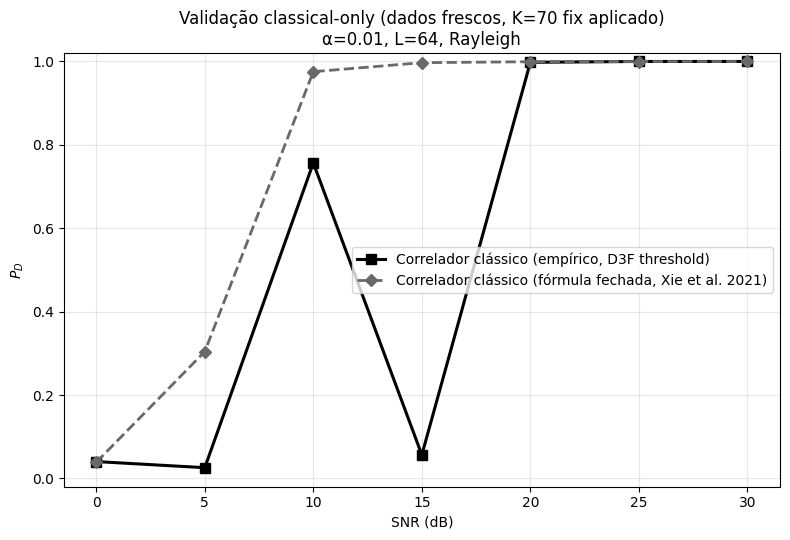

In [7]:
CLASSICAL_PD_EMPIRICO = {}
CLASSICAL_PD_FECHADO  = {}

for snr in SNR_BINS:
    m0 = (snr_val_arr  >= snr-2.5) & (snr_val_arr  < snr+2.5) & (lbl_val_arr  == 0)
    m1 = (snr_test_arr >= snr-2.5) & (snr_test_arr < snr+2.5) & (lbl_test_arr == 1)
    if m0.sum() < 50 or m1.sum() < 10:
        CLASSICAL_PD_EMPIRICO[snr] = 0.0
    else:
        mu, sig = tau_val_arr[m0].mean(), tau_val_arr[m0].std()
        thr = float(mu + Q_INV_D3F * sig) if sig > 1e-10 else 0.0
        CLASSICAL_PD_EMPIRICO[snr] = float((tau_test_arr[m1] >= thr).mean()) if sig > 1e-10 else 0.0

    _, pd_cf = xie_closed_form_rayleigh(L_FIXED, RHO_T, snr, ALPHA_D3F)
    CLASSICAL_PD_FECHADO[snr] = pd_cf

print("SNR(dB)  Empirico  Fechado(Xie)  Diferenca")
for snr in SNR_BINS:
    e, f = CLASSICAL_PD_EMPIRICO[snr], CLASSICAL_PD_FECHADO[snr]
    print(f"  {snr:2d}     {e:.4f}    {f:.4f}      {e-f:+.4f}")

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(SNR_BINS, [CLASSICAL_PD_EMPIRICO[s] for s in SNR_BINS],
        'k-s', linewidth=2.2, markersize=7, label='Correlador clássico (empírico, D3F threshold)')
ax.plot(SNR_BINS, [CLASSICAL_PD_FECHADO[s] for s in SNR_BINS],
        color='dimgray', linestyle='--', marker='D', linewidth=2.0, markersize=6,
        label='Correlador clássico (fórmula fechada, Xie et al. 2021)')
ax.set_xlabel('SNR (dB)'); ax.set_ylabel('$P_D$')
ax.set_title('Validação classical-only (dados frescos, K=70 fix aplicado)\n'
              f'α={ALPHA_D3F}, L={L_FIXED}, Rayleigh')
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.savefig('classical_only_validation.png', dpi=120)
plt.show()

## 7. Interpretação

- **Se as duas curvas praticamente coincidirem** aqui (dados 100% frescos,
  gerados com o `K=70` já corrigido): confirma que o gerador está correto,
  e a divergência que vocês viram no `NN_02c` vem do `.h5` de 300k amostras
  estar **desatualizado** (gerado antes da correção). Solução: reexecutar
  Seção 4 (geração) + Seção 6 (salvar HDF5) do `NN_01`, então rerodar
  `NN_02c` — aí sim vale esperar o treino de ~4h, já sobre dados corretos.
- **Se a divergência persistir mesmo aqui**: o problema NÃO é o dataset
  desatualizado — é algo na fórmula ou no pipeline que ainda precisa de
  investigação, e vocês pouparam as 4h de treino testando isso antes.

Rode este notebook (não depende de GPU nem do `.h5` grande) toda vez que
mudar algo no gerador de dados/fórmula fechada, antes de comprometer tempo
de treino da rede.